In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from transformers import GPT2Model,GPT2Tokenizer
from transformers import BertTokenizer, BertModel

In [2]:

gpt2 = GPT2Model.from_pretrained('gpt2')
tokenizerG = GPT2Tokenizer.from_pretrained('gpt2')


tokenizerB = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
print(gpt2)

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [4]:
print(bert)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [5]:
print(f'BERT has {tokenizerB.vocab_size:,} tokens.')
print(f'GPT2 has {tokenizerG.vocab_size:,} tokens.')

BERT has 30,522 tokens.
GPT2 has 50,257 tokens.


In [10]:
# GPT: get all individual lengths
token_lengths = np.zeros(tokenizerG.vocab_size, dtype=int)

for idx in range(tokenizerG.vocab_size):
  token_lengths[idx] = len(tokenizerG.decode(idx))

uniqueLengthsG,tokenCountG = np.unique(token_lengths,return_counts=True)


# BERT
token_lengths = np.zeros(tokenizerB.vocab_size, dtype=int)
for idx,word in enumerate(tokenizerB.get_vocab().keys()):
  token_lengths[idx] = len(word)

uniqueLengthsB,tokenCountB = np.unique(token_lengths,return_counts=True)

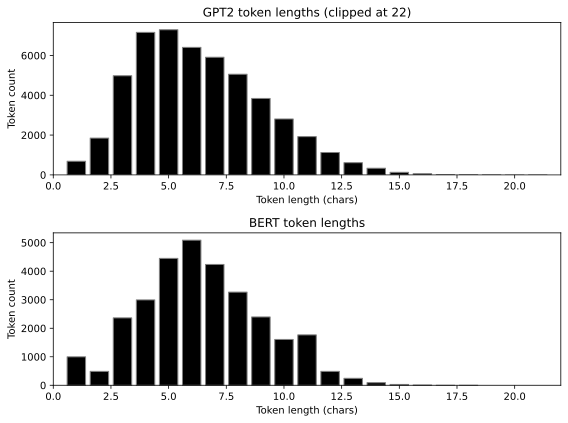

In [11]:
# draw the barplot!
_,axs = plt.subplots(2,1,figsize=(8,6))
axs[0].bar(uniqueLengthsG,tokenCountG,color='k',edgecolor='gray')
axs[0].set(xlabel='Token length (chars)',ylabel='Token count',title='GPT2 token lengths (clipped at 22)',
           xlim=[0,22])

axs[1].bar(uniqueLengthsB,tokenCountB,color='k',edgecolor='gray')
axs[1].set(xlabel='Token length (chars)',ylabel='Token count',title='BERT token lengths',
           xlim=[0,22])

plt.tight_layout()
plt.show()

In [12]:
# get the Word Token Embeddings matrix
embeddingsG = gpt2.wte.weight.detach().numpy()

# get the word token embeddings matrix (note the different variable names compared to GPT2!
embeddingsB = bert.embeddings.word_embeddings.weight.detach().numpy()

# print their sizes
print(f'BERT embedding matrix is of size {embeddingsB.shape}.')
print(f'GPT2 embedding matrix is of size {embeddingsG.shape}.')

BERT embedding matrix is of size (30522, 768).
GPT2 embedding matrix is of size (50257, 768).


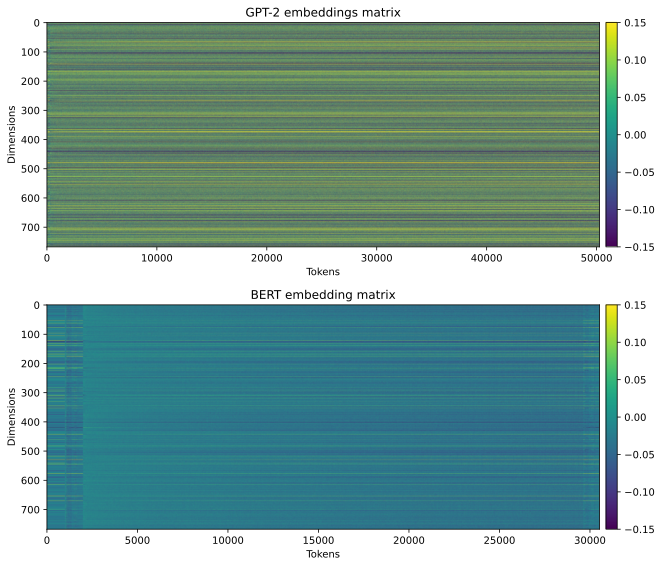

In [14]:
fig,axs = plt.subplots(2,1,figsize=(10,8))

# GPT embeddings
h = axs[0].imshow(embeddingsG.T,aspect='auto',vmin=-.15,vmax=.15)
axs[0].set(xlabel='Tokens',ylabel='Dimensions',title='GPT-2 embeddings matrix')
fig.colorbar(h,ax=axs[0],pad=.01)

# BERT embeddings
h = axs[1].imshow(embeddingsB.T,aspect='auto',vmin=-.15,vmax=.15)
axs[1].set(xlabel='Tokens',ylabel='Dimensions',title='BERT embedding matrix')
fig.colorbar(h,ax=axs[1],pad=.01)

plt.tight_layout()
plt.show()

Comparing The same token index

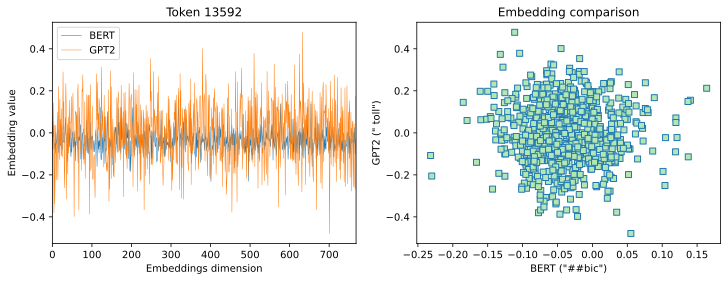

In [15]:
# pick a random token index
ridx = np.random.randint(10000,20000)

_,axs = plt.subplots(1,2,figsize=(12,4))

axs[0].plot(embeddingsB[ridx,:],label='BERT',linewidth=.5)
axs[0].plot(embeddingsG[ridx,:],label='GPT2',linewidth=.5)
axs[0].legend()
axs[0].set(xlabel='Embeddings dimension',ylabel='Embedding value',xlim=[0,embeddingsB.shape[1]],title=f'Token {ridx}')

axs[1].plot(embeddingsB[ridx,:],embeddingsG[ridx,:],'s',markerfacecolor=[.7,.9,.7])
axs[1].set(xlabel=f'BERT ("{tokenizerB.decode(ridx)}")',ylabel=f'GPT2 ("{tokenizerG.decode(ridx)}")',
           title='Embedding comparison')

plt.show()

In [16]:
token = 'the'
token_idxB = tokenizerB.encode(token)[1]
token_idxG = tokenizerG.encode(token)[0]

print(f'BERT: "{token}" is index {token_idxB}')
print(f'GPT2: "{token}" is index {token_idxG}')

BERT: "the" is index 1996
GPT2: "the" is index 1169


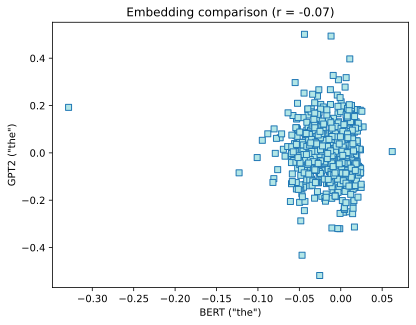

In [17]:
# their correlation
corr = np.corrcoef(embeddingsB[token_idxB,:],embeddingsG[token_idxG,:])

plt.plot(embeddingsB[token_idxB,:],embeddingsG[token_idxG,:],'s',markerfacecolor=[.7,.9,.9])
plt.gca().set(xlabel=f'BERT ("{tokenizerB.decode(token_idxB)}")',ylabel=f'GPT2 ("{tokenizerG.decode(token_idxG)}")',
           title=f'Embedding comparison (r = {corr[0,1]:.2f})')

plt.show()

# Distributions of embeddings characteristics

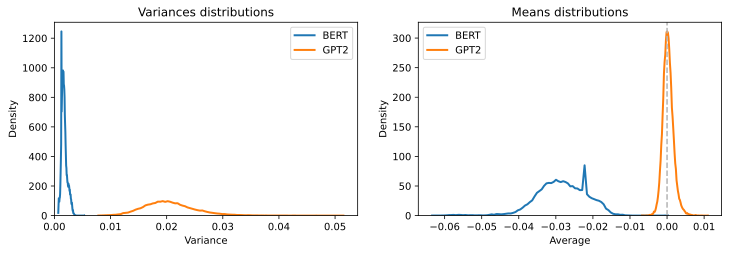

In [18]:
_,axs = plt.subplots(1,2,figsize=(12,3.5))

# compare the embeddings variances
yB,xB = np.histogram(embeddingsB.var(axis=1),bins=100,density=True)
yG,xG = np.histogram(embeddingsG.var(axis=1),bins=100,density=True)

axs[0].plot(xB[:-1],yB,linewidth=2,label='BERT')
axs[0].plot(xG[:-1],yG,linewidth=2,label='GPT2')
axs[0].set(xlabel='Variance',ylabel='Density',xlim=[0,None],ylim=[0,None],title='Variances distributions')
axs[0].legend()

# compare the embeddings means
yB,xB = np.histogram(embeddingsB.mean(axis=1),bins=100,density=True)
yG,xG = np.histogram(embeddingsG.mean(axis=1),bins=100,density=True)

axs[1].plot(xB[:-1],yB,linewidth=2,label='BERT')
axs[1].plot(xG[:-1],yG,linewidth=2,label='GPT2')
axs[1].axvline(0,color=[.7,.7,.7],linestyle='--')
axs[1].set(xlabel='Average',ylabel='Density',ylim=[0,None],title='Means distributions')
axs[1].legend()


plt.show()